<a href="https://colab.research.google.com/github/kanickz/NN_framework/blob/main/NN_FRAMEWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the dataset (60,000 training images, 10,000 testing images)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [ ]:
# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# Reshape data for the input layer (28*28 = 784)
train_images = train_images.reshape((60000, 784))
test_images = test_images.reshape((10000, 784))

# One-hot encode the labels (e.g., 3 becomes [0,0,0,1,0,0,0,0,0,0])
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [ ]:
model = models.Sequential([
    # Input layer + First Hidden Layer
    layers.Dense(512, activation='relu', input_shape=(784,)),

    # Second Hidden Layer (to manage model complexity)
    layers.Dense(256, activation='relu'),

    # Output layer with 10 units (one for each digit)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2 # Useful for checking overfitting
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8390 - loss: 0.6407 - val_accuracy: 0.9153 - val_loss: 0.3085
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9184 - loss: 0.2905 - val_accuracy: 0.9305 - val_loss: 0.2441
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9324 - loss: 0.2377 - val_accuracy: 0.9407 - val_loss: 0.2103
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9421 - loss: 0.2030 - val_accuracy: 0.9474 - val_loss: 0.1860
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9498 - loss: 0.1781 - val_accuracy: 0.9534 - val_loss: 0.1692
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9554 - loss: 0.1578 - val_accuracy: 0.9584 - val_loss: 0.1528
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9600 - loss: 0.1417 - val_accuracy: 0.9596 - val_loss: 0.1447
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9637 - loss: 0

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Make a prediction on a single image
import numpy as np
prediction = model.predict(test_images[0:1])
predicted_digit = np.argmax(prediction)

print(f"Predicted Digit: {predicted_digit}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9650 - loss: 0.1174

Test Accuracy: 96.50%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Digit: 7


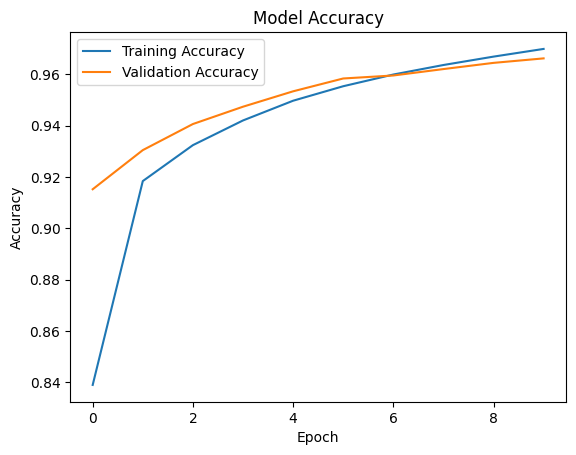

In [ ]:
# Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import collections

# Get the raw labels before one-hot encoding for counting
(_, raw_labels), (_, _) = tf.keras.datasets.mnist.load_data()
counts = collections.Counter(raw_labels)
print("Class distribution:", sorted(counts.items()))

Class distribution: [(np.uint8(0), 5923), (np.uint8(1), 6742), (np.uint8(2), 5958), (np.uint8(3), 6131), (np.uint8(4), 5842), (np.uint8(5), 5421), (np.uint8(6), 5918), (np.uint8(7), 6265), (np.uint8(8), 5851), (np.uint8(9), 5949)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


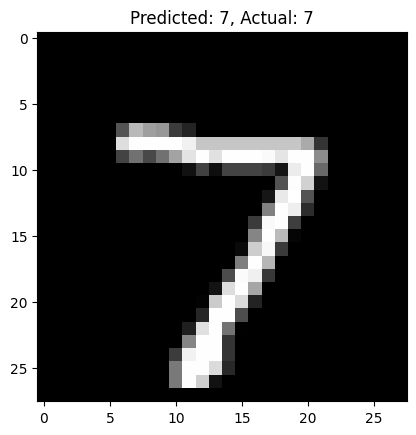

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


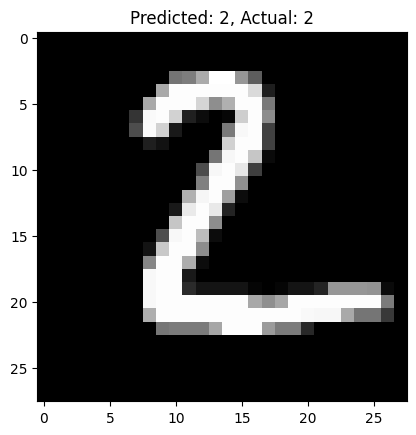

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


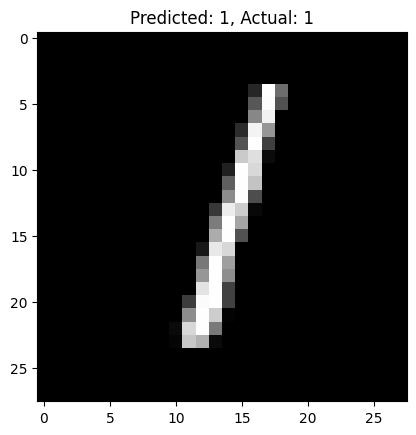

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


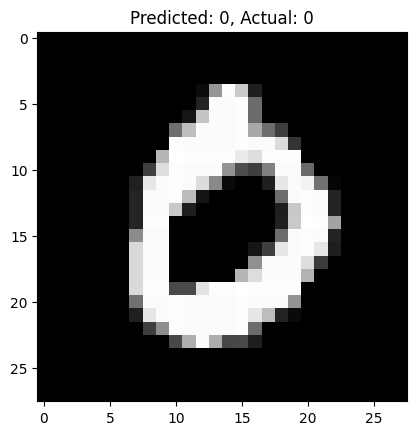

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


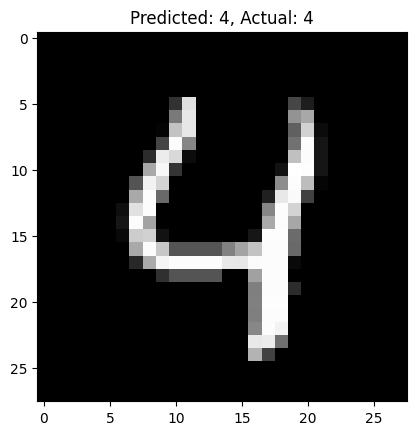

In [ ]:
# Show first 5 test images and predictions
for i in range(5):
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    pred = model.predict(test_images[i:i+1])
    plt.title(f"Predicted: {np.argmax(pred)}, Actual: {np.argmax(test_labels[i])}")
    plt.show()

In [ ]:
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])